In [2]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.sampling import run_metropolis
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

In [3]:
mode_labels = [0, 1]
flows_dic = [load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]

In [3]:
mlps_models = [mlps_dic[mode_label]['model'] for mode_label in mode_labels]

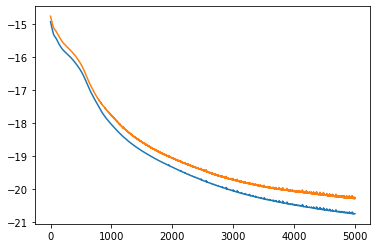

In [4]:
plt.plot(flows_dic[0]['losses'][0])
plt.plot(flows_dic[0]['losses'][1])

In [5]:
weights = torch.tensor([0.5, 0.5])
mixture = Mixture(get_models(flows_dic), weights)

In [15]:
mode_labels = [0, 1]
dataset_label = 'md_train'
# dataset_labels = ['md_train', 'md_test', 'flow_train', 'flow_test']
coord_mapping = Coordinates_mapping()

zmats = []
xs = []
for mode_label in mode_labels:
    file='datasets/is{:d}_{:s}.csv'.format(mode_label, dataset_label)
    zmat = load_csv_file(file)
    
    x, logdetjac, energies = coord_mapping.get_real_centered_from_internal(zmat[:, :12], 
                                                                        zmat[:, 12],  
                                                                        isomer=mode_label,
                                                                        energies=zmat[:, 13])
    x = join_data(x, energies, zmat[:, 14], logdetjac,)
    
    zmats.append(zmat)
    xs.append(x)

xs = torch.cat(xs)
x_mds = xs

In [7]:
x_mds.shape

torch.Size([8000, 15])

In [9]:
x_u_is_init = xs
# x_u_is_init[:, 14] 
# x_u_is_init.shape
mcmc_run = run_metropolis(mixture, init=x_u_is_init, n_chains=x_u_is_init.shape[0], n_steps=5, mixture=True, mlp_models=mlps_models, energy_type='mlp', with_tqdm=True)

acc: 0.29: 100%|██████████| 5/5 [00:25<00:00,  5.18s/it]


In [10]:
mcmc_run.keys()

dict_keys(['xs', 'us', 'accs', 'isomers'])

In [11]:
from flonacomldft.free_energy_computations import compute_TFP_logratio, compute_deepBAR_logratio

In [12]:
target_log_probs = mlps_models
n_prop = 8000
mix_prop = get_models(flows_dic)

log_ratio_TFPs = []
log_err_TFPs = []
for trial in range(10):
    log_ratio_TFP, log_err_TFP = compute_TFP_logratio(n_prop, target_log_probs, mix_prop)

    log_ratio_TFPs.append(log_ratio_TFP)
    log_err_TFPs.append(log_err_TFP)

log_ratio_TFPs = np.array(log_ratio_TFPs)
log_err_TFPs = np.array(log_err_TFPs)

print(
    'log_ratio_TFPs: {:.3e} +/- {:.3e}'.format(log_ratio_TFPs.mean(), log_ratio_TFPs.std()),
    'log_err_TFPs: {:.3e} +/- {:.3e}'.format(log_err_TFPs.mean(), log_err_TFPs.std())
)

log_ratio_TFPs: 3.074e-01 +/- 1.953e+00 log_err_TFPs: 1.480e-08 +/- 2.261e-08


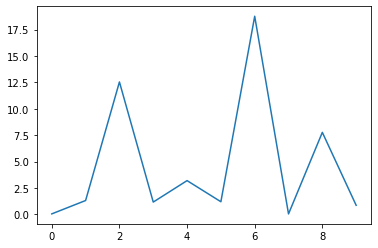

In [23]:
plt.plot(np.exp(log_ratio_TFPs))

In [13]:
xs = mcmc_run['xs'].reshape(-1, 12)
isomers = mcmc_run['isomers'].reshape(-1)

log_ratio_deepBARs = []
log_err_deepBARs = []

for trial in range(10):
    log_ratio_deepBAR, log_err_deepBAR = compute_deepBAR_logratio(xs, isomers, target_log_probs, mix_prop)

    log_ratio_deepBARs.append(log_ratio_deepBAR)
    log_err_deepBARs.append(log_err_deepBAR)

log_ratio_deepBARs = np.array(log_ratio_deepBARs)
log_err_deepBARs = np.array(log_err_deepBARs)

print(
    'log_ratio_deepBARs: {:.3e} +/- {:.3e}'.format(log_ratio_deepBARs.mean(), log_ratio_deepBARs.std()),
    'log_err_deepBARs: {:.3e} +/- {:.3e}'.format(log_err_deepBARs.mean(), log_err_deepBARs.std())
)

IndexError: The shape of the mask [40000] at index 0 does not match the shape of the indexed tensor [8000, 15] at index 0

In [21]:
xs = x_mds[:, :12]
isomers = x_mds[:, 13]


log_ratio_deepBARs = []
log_err_deepBARs = []

for trial in range(10):
    log_ratio_deepBAR, log_err_deepBAR = compute_deepBAR_logratio(xs, isomers, target_log_probs, mix_prop)

    log_ratio_deepBARs.append(log_ratio_deepBAR)
    log_err_deepBARs.append(log_err_deepBAR)

log_ratio_deepBARs = np.array(log_ratio_deepBARs)
log_err_deepBARs = np.array(log_err_deepBARs)

print(
    'log_ratio_deepBARs: {:.3e} +/- {:.3e}'.format(log_ratio_deepBARs.mean(), log_ratio_deepBARs.std()),
    'log_err_deepBARs: {:.3e} +/- {:.3e}'.format(log_err_deepBARs.mean(), log_err_deepBARs.std())
)

/Users/marylou/Dropbox/Prof/Experiments/ml-dft/ML-DFT/packages/flonaco-ml-dft/flonacomldft/free_energy_computations.py:164: UserWarning: Error estimation misses ESS estimation
  xs_mode = xs[cs == mode]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 4.5958741168306005e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.27938086791346e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -1.7030974674980826e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -2.4820952759796455e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/

log_ratio_deepBARs: 9.379e-01 +/- 1.141e+00 log_err_deepBARs: 9.865e-01 +/- 2.308e-01


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 6.840447746014888e-07 reached.
  warnings.warn(msg, RuntimeWarning)


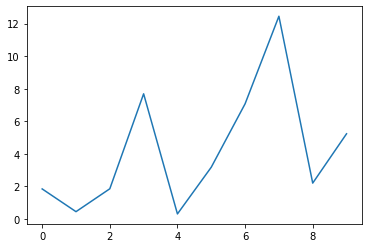

In [24]:
plt.plot(np.exp(log_ratio_deepBARs))

# Per isomer test

In [25]:
from flonacomldft.free_energy_computations import compute_TFP, compute_BAR

In [44]:
n_prop = 8000
prop = get_models(flows_dic)[0]
target_log_prob = mlps_models[0]

log_ratio_0_TFPs = []
log_err_0_TFPs = []

for trial in range(10):
    logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_prob, prop)
    log_ratio_0_TFPs.append(logr_TFP_0)
    log_err_0_TFPs.append(log_err_TFP_0)

print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_TFPs).mean(), np.array(log_ratio_0_TFPs).std()))

logr_TFP 1.646e+01 +/- 2.047e+00


In [45]:
n_prop = 8000
prop = get_models(flows_dic)[1]
target_log_prob = mlps_models[1]

log_ratio_1_TFPs = []
log_err_1_TFPs = []

for trial in range(10):
    logr_TFP_1, log_err_TFP_1 = compute_TFP(n_prop, target_log_prob, prop)
    log_ratio_1_TFPs.append(logr_TFP_1)
    log_err_1_TFPs.append(log_err_TFP_1)

print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_1_TFPs).mean(), np.array(log_ratio_1_TFPs).std()))

logr_TFP 1.664e+01 +/- 7.507e-01


In [46]:
n_prop = 8000
prop = get_models(flows_dic)[0]
target_log_prob = mlps_models[0]
xs = x_mds[:, :12][x_mds[:, 13] == 0]

log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(10):
    logr_BAR_0, log_err_BAR_0 = compute_BAR(xs, target_log_prob, prop, n_prop)
    log_ratio_0_BARs.append(logr_BAR_0)
    log_err_0_BARs.append(log_err_BAR_0)

print('logr_BAR {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_BARs).mean(), np.array(log_ratio_0_BARs).std()))

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 5.288186812890672e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -4.0361834763302795e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 7.647726683046585e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.3522372433480996e-08 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -2.2642487351731688e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Use

logr_BAR 1.754e+01 +/- 6.833e-01


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -4.0918320109994966e-07 reached.
  warnings.warn(msg, RuntimeWarning)


In [47]:
n_prop = 8000
prop = get_models(flows_dic)[1]
target_log_prob = mlps_models[1]
xs = x_mds[:, :12][x_mds[:, 13] == 1]

log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(10):
    logr_BAR_1, log_err_BAR_1 = compute_BAR(xs, target_log_prob, prop, n_prop)
    log_ratio_1_BARs.append(logr_BAR_1)
    log_err_1_BARs.append(log_err_BAR_1)

print('logr_BAR {:.3e} +/- {:.3e}'.format(np.array(log_ratio_1_BARs).mean(), np.array(log_ratio_1_BARs).std()))

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 4.689095050025571e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 2.44246503910972e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.8033552129945747e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -4.902478316637371e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -7.957796377411341e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/

logr_BAR 1.718e+01 +/- 1.113e+00


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.1908727393670233e-07 reached.
  warnings.warn(msg, RuntimeWarning)


([<matplotlib.axis.XTick at 0x7fac27b26cd0>,
 [Text(1, 0, 'BAR 0'),
  Text(2, 0, 'TFP 0'),
  Text(3, 0, 'BAR 1'),
  Text(4, 0, 'TFP 1')])

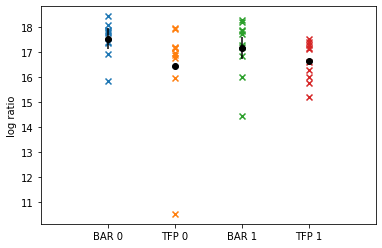

In [68]:
plt.scatter(np.ones(10), log_ratio_0_BARs, marker='x')
plt.errorbar([1], np.array(log_ratio_0_BARs).mean(), yerr=np.array(log_err_0_BARs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 2, log_ratio_0_TFPs, marker='x')
plt.errorbar([2], np.array(log_ratio_0_TFPs).mean(), yerr=np.array(log_err_0_TFPs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 3, log_ratio_1_BARs, marker='x')
plt.errorbar([3], np.array(log_ratio_1_BARs).mean(), yerr=np.array(log_err_1_BARs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 4, log_ratio_1_TFPs, marker='x')
plt.errorbar([4], np.array(log_ratio_1_TFPs).mean(), yerr=np.array(log_err_1_TFPs).mean(), marker='o', color='k')

plt.xlim(0,5)
plt.ylabel('log ratio')
plt.xticks([1,2,3,4], ['BAR 0', 'TFP 0', 'BAR 1', 'TFP 1'])
# plt.plot(np.exp(log_ratio_0_TFPs))
# plt.xlabel('trial')
# plt.ylabel('ratio model - data')

Conclusion: Ici l'information est perdu dans la variance s'il s'agit de faire la différence des deux quantités

# Looking at the acceptance with the trained flows - within a mode

In [10]:
from flonacomldft.train_flow_from_data import get_ratio_acc

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

coord_mapping = Coordinates_mapping()

In [29]:
# trained
flows = get_models(flows_dic)
mlps = get_models(mlps_dic)

Final ratio mean: 6.579e-01
Final ratio mean: 6.133e-01


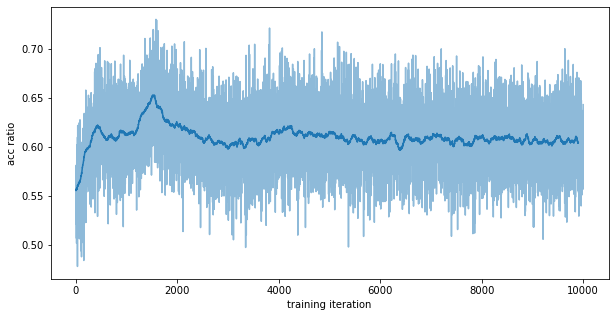

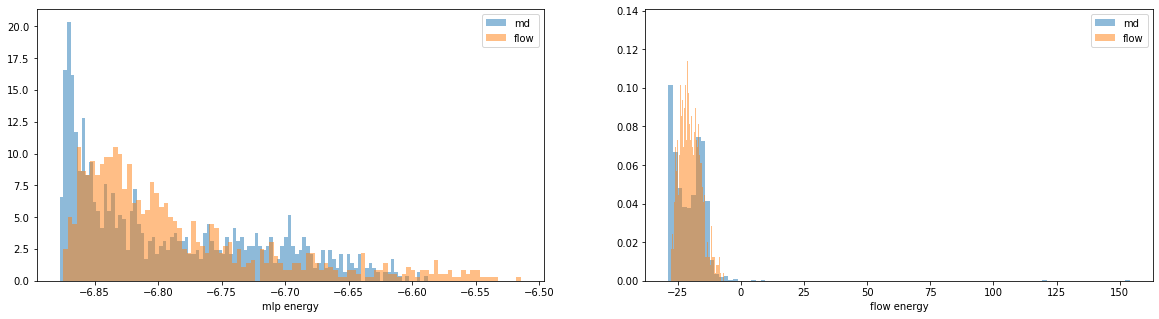

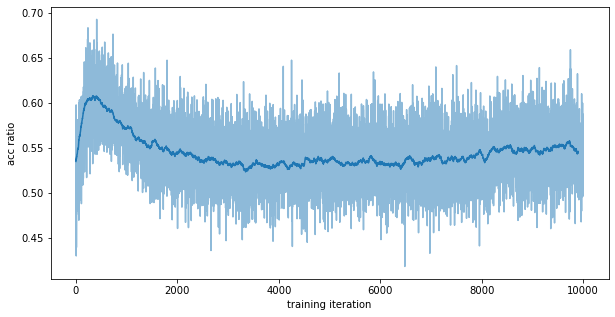

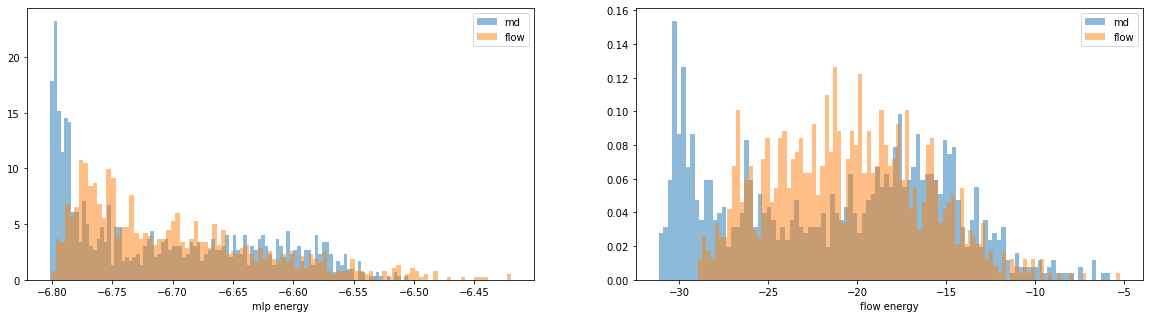

In [33]:
for mode_label in [0, 1]:
    zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

    xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                        zmat_test[:, :12],
                                        isomer=mode_label,
                                        energies=zmat_test[:, 12],
                                        logdetjacs=zmat_test[:, 14],
                                        )
    xs_test = xs_test.to(torch.float32)
    test = join_data(xs_test,
                    energies_test,
                    zmat_test[:, 13],
                    logdetjacs_test,
    )

    n_chains = 1000
    init = test[:n_chains]
    ratio, acc = get_ratio_acc(flows[mode_label], init, init.shape[0], mlps[mode_label])
    print('Final ratio mean: {:.3e}'.format(ratio.mean()))

    plt.figure(figsize=(10,5))
    plt.plot(flows_dic[mode_label]['ratios'], alpha=0.5)
    plt.plot(moving_average(flows_dic[mode_label]['ratios'], 100), c='C0')
    plt.xlabel('training iteration')
    plt.ylabel('acc ratio')

    plt.figure(figsize=(20,5))
    xs_flow = flows[mode_label].sample(xs_test.shape[0])
    ax = plt.subplot(1,2,1)
    plt.hist(mlps[mode_label](xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='md')
    plt.hist(mlps[mode_label](xs_flow).detach().numpy(), bins=100, alpha=0.5, density=True, label='flow')
    plt.xlabel('mlp energy')
    plt.legend()
    ax = plt.subplot(1,2,2)
    plt.hist(flows[mode_label].nll(xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='md')
    plt.hist(flows[mode_label].nll(xs_flow).detach().numpy(), bins=100, alpha=0.5, density=True, label='flow')
    plt.xlabel('flow energy')
    plt.legend()

Untrained:

initial ratio mean: 5.886e-01
initial ratio mean: 5.312e-01


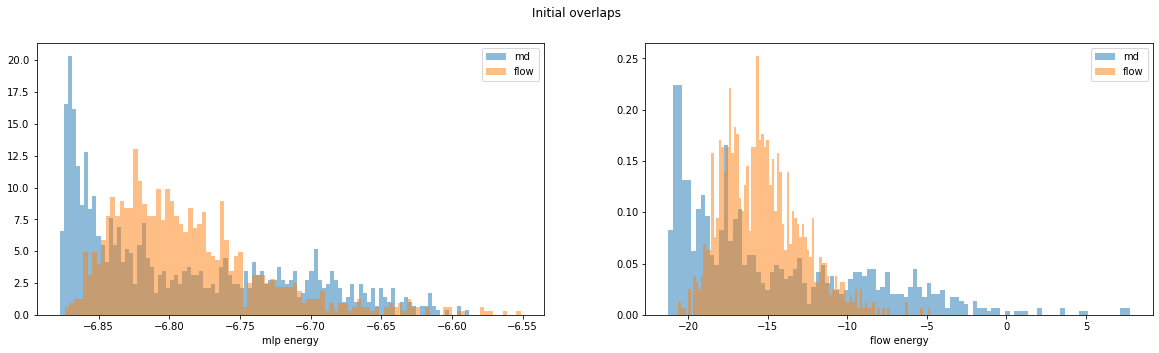

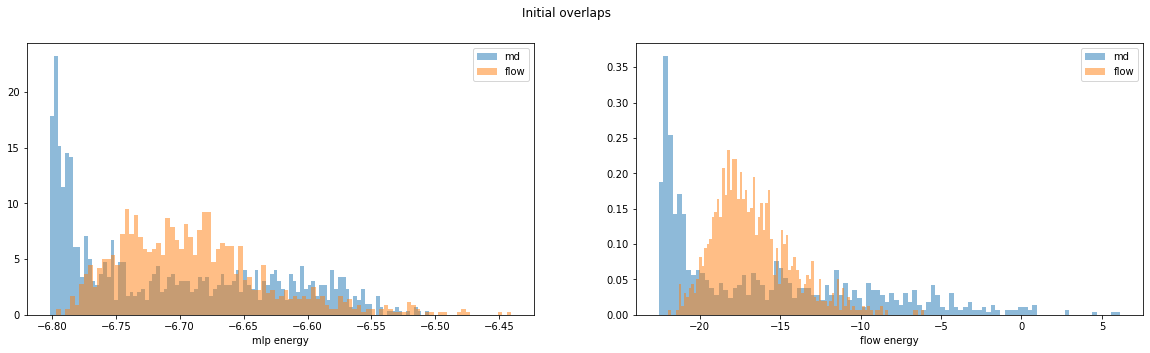

In [68]:
for mode_label in [0, 1]:
    zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

    xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                        zmat_test[:, :12],
                                        isomer=mode_label,
                                        energies=zmat_test[:, 12],
                                        logdetjacs=zmat_test[:, 14],
                                        )
    xs_test = xs_test.to(torch.float32)
    test = join_data(xs_test,
                    energies_test,
                    zmat_test[:, 13],
                    logdetjacs_test,
    )

    n_chains = 1000
    init = test[:n_chains]
    
    init_flow = flows_dic[mode_label]['models'][0]

    ratio, acc = get_ratio_acc(init_flow, init, init.shape[0], mlps[mode_label])
    print('initial ratio mean: {:.3e}'.format(ratio.mean()))

    plt.figure(figsize=(20,5))
    plt.suptitle('Initial overlaps')
    xs_flow = init_flow.sample(xs_test.shape[0])
    ax = plt.subplot(1,2,1)
    plt.hist(mlps[mode_label](xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='md')
    plt.hist(mlps[mode_label](xs_flow).detach().numpy(), bins=100, alpha=0.5, density=True, label='flow')
    plt.xlabel('mlp energy')
    plt.legend()
    ax = plt.subplot(1,2,2)
    plt.hist(init_flow.nll(xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='md')
    plt.hist(init_flow.nll(xs_flow).detach().numpy(), bins=100, alpha=0.5, density=True, label='flow')
    plt.xlabel('flow energy')
    plt.legend()

Comparing the flows energy distribution after training

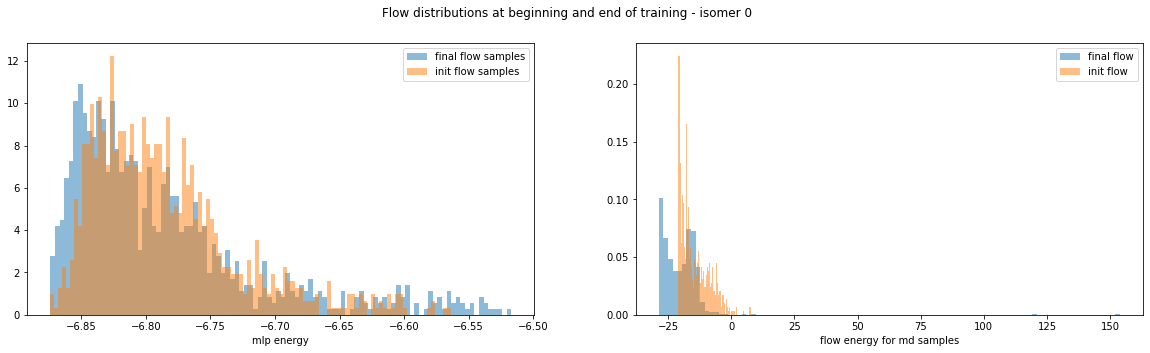

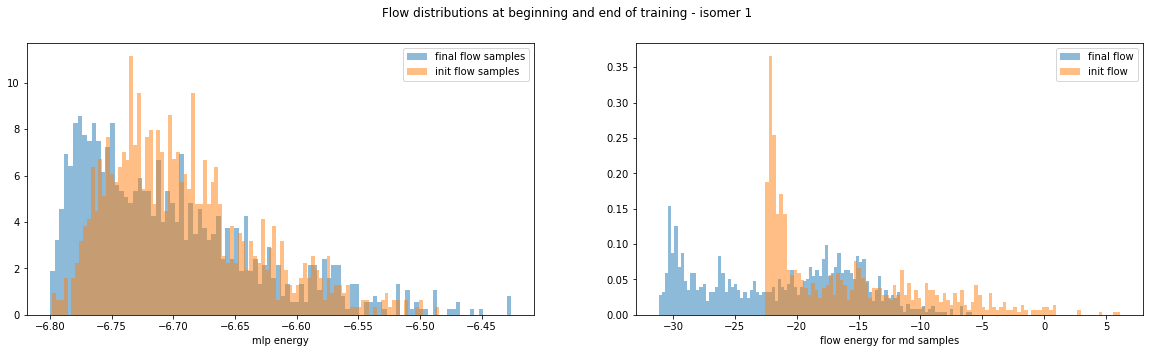

In [73]:
for mode_label in [0, 1]:
    zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

    xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                        zmat_test[:, :12],
                                        isomer=mode_label,
                                        energies=zmat_test[:, 12],
                                        logdetjacs=zmat_test[:, 14],
                                        )
    xs_test = xs_test.to(torch.float32)
    
    init_flow = flows_dic[mode_label]['models'][0]
    final_flow = flows[mode_label]

    n_chains = 1000

    plt.figure(figsize=(20,5))
    plt.suptitle('Flow distributions at beginning and end of training - isomer {:d}'.format(mode_label))
    xs_flow_init = init_flow.sample(n_chains)
    xs_flow_final = final_flow.sample(n_chains)
    ax = plt.subplot(1,2,1)
    plt.hist(mlps[mode_label](xs_flow_final).detach().numpy(), bins=100, alpha=0.5, density=True, label='final flow samples')
    plt.hist(mlps[mode_label](xs_flow_init).detach().numpy(), bins=100, alpha=0.5, density=True, label='init flow samples')
    plt.xlabel('mlp energy')
    plt.legend()
    ax = plt.subplot(1,2,2)
    plt.hist(final_flow.nll(xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='final flow')
    plt.hist(init_flow.nll(xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='init flow')
    plt.xlabel('flow energy for md samples')
    plt.legend()

acc: 0.08: 100%|██████████| 100/100 [00:17<00:00,  5.65it/s]


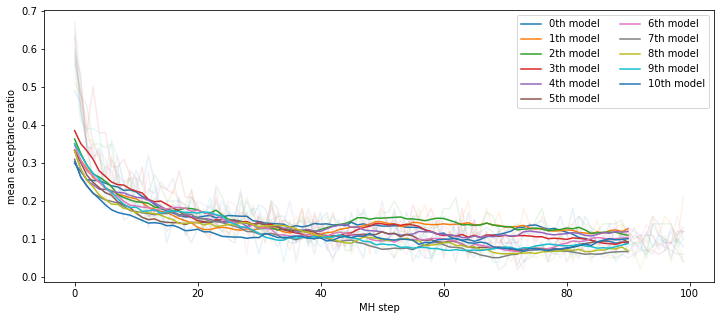

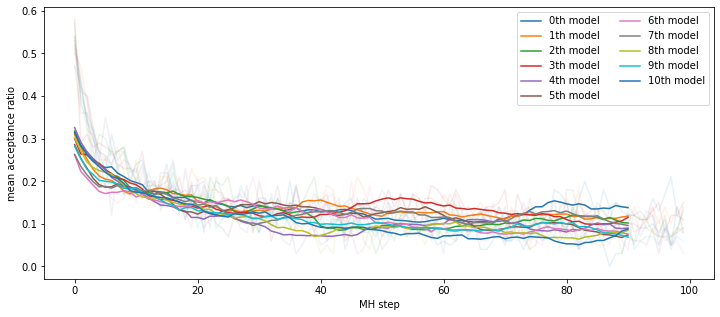

In [56]:
for mode_label in [0, 1]:
    mcmc_runs = []
    for flow in flows_dic[mode_label]['models']:
        zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

        xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                            zmat_test[:, :12],
                                            isomer=mode_label,
                                            energies=zmat_test[:, 12],
                                            logdetjacs=zmat_test[:, 14],
                                            )
        xs_test = xs_test.to(torch.float32)
        test = join_data(xs_test,
                        energies_test,
                        zmat_test[:, 13],
                        logdetjacs_test,
        )

        n_chains = 100
        init = test[:n_chains]
        mcmc_run = run_metropolis(flow, init, init.shape[0], n_steps=100, energy_type='mlp', mlp_models=mlps[mode_label], with_tqdm=True)
        mcmc_runs.append(mcmc_run)

    plt.figure(figsize=(12,5))
    for d,mcmc_run in enumerate(mcmc_runs):
        _ = plt.plot((mcmc_run['accs'] * 1.).mean(1), alpha=0.1)
        plt.plot(moving_average((mcmc_run['accs'] * 1.).mean(1), 10), c=_[0].get_color(), label='{:d}th model'.format(d))
    plt.xlabel('MH step')
    plt.ylabel('mean acceptance ratio')
    plt.legend(ncol=2)

Text(0, 0.5, 'mlp energy')

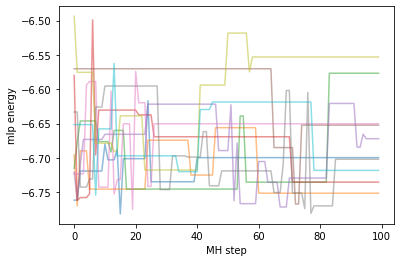

In [66]:
plt.plot((mcmc_run['us'][:, :10]).detach().numpy(), alpha=0.5)
plt.xlabel('MH step')
plt.ylabel('mlp energy')